# Step 3b — Adversarial strength sweep (does GRL remove culture at all?)

In Step 3 the fresh culture probe stayed at ~99% for every GRL variant, and λ was chosen per fold from {0.05, 0.1, 0.2, 0.5}. This notebook fixes λ at **0, 1, 2, 5 and 10** (no per-fold selection) and measures the **trade-off curve**: culture leakage in `z` vs. balanced accuracy and fairness.

Variants per backbone:
- `grl`: plain GRL, no culture conditioning (original paper setup)
- `ccal_soft`: label-conditional GRL + culture FiLM + soft labels (best Step 3 configuration)

**Kaggle settings:** GPU T4, Internet On. Takes about 1–1.5 h. Run with **Save Version → Save & Run All**; finished runs are skipped if you re-run.

In [7]:
import glob, json, math, os, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from types import SimpleNamespace
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier
import warnings; warnings.filterwarnings("ignore", category=UserWarning)

def find(name):
    hits = glob.glob(f"/kaggle/input/**/{name}", recursive=True) + glob.glob(f"/kaggle/working/**/{name}", recursive=True)
    return hits[0] if hits else None

FEATURES = {"openclip_b32": find("feats_openclip_b32.npz"), "siglip2": find("feats_siglip2.npz")}
print("Attached inputs:", os.listdir("/kaggle/input") if os.path.exists("/kaggle/input") else "none")
print("Found features :", FEATURES)
if not all(FEATURES.values()):
    print("\nFeature files not found as input -> building them here (needs GPU + Internet On, ~5 min).")
RESULTS = "/kaggle/working/results_sweep"
os.makedirs(RESULTS, exist_ok=True)

Attached inputs: []
Found features : {'openclip_b32': '/kaggle/working/feats_openclip_b32.npz', 'siglip2': '/kaggle/working/feats_siglip2.npz'}


In [8]:
# ---- Build features in this notebook if they were not attached as input (same code as Step 2) ----
if not all(FEATURES.values()):
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers>=4.49", "open_clip_torch"], check=True)
    from PIL import Image

    REPO = "/kaggle/working/Multi3Hate"
    if not os.path.exists(REPO):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/MinhDucBui/Multi3Hate.git", REPO], check=True)
    DATA = f"{REPO}/data"
    LANG2CULT = {"en": "US", "de": "DE", "es": "MX", "hi": "IN", "zh": "CN"}
    final = pd.read_csv(f"{DATA}/final_annotations.csv")
    raw = pd.read_csv(f"{DATA}/raw_annotations.csv").dropna(subset=["hatespeech"])
    votes = raw.groupby(["dataset_language", "Meme ID"])["hatespeech"].agg(n_hate="sum", n_total="count")
    img_index = {(p.split("/")[-3], int(os.path.splitext(os.path.basename(p))[0])): p
                 for p in glob.glob(f"{DATA}/memes/*/*/*")}
    rows = []
    for lang, cult in LANG2CULT.items():
        for _, r in pd.read_csv(f"{DATA}/captions/{lang}.csv").iterrows():
            mid = int(r["Meme ID"])
            v = votes.loc[(lang, mid)]
            rows.append({"meme_id": mid, "culture": cult, "language": lang,
                         "image_path": img_index[(lang, mid)],
                         "text": str(r["Translation"]).replace("<sep>", " / "),
                         "n_hate": int(v["n_hate"]), "n_total": int(v["n_total"]),
                         "label": int(final.loc[final["Meme ID"] == mid, cult].iloc[0])})
    df = pd.DataFrame(rows).sort_values(["meme_id", "culture"]).reset_index(drop=True)
    df.to_csv("/kaggle/working/multi3hate.csv", index=False)
    print("table:", df.shape)

    DEVICE_FE = "cuda" if torch.cuda.is_available() else "cpu"

    def as_tensor(out):
        if isinstance(out, torch.Tensor):
            return out
        for key in ("pooler_output", "image_embeds", "text_embeds"):
            v = getattr(out, key, None)
            if isinstance(v, torch.Tensor):
                return v
        raise TypeError(type(out))

    def load_backend(name):
        if name == "siglip2":
            from transformers import AutoModel, AutoProcessor
            mid = "google/siglip2-base-patch16-224"
            model = AutoModel.from_pretrained(mid).to(DEVICE_FE).eval()
            proc = AutoProcessor.from_pretrained(mid)
            enc_img = lambda ims: as_tensor(model.get_image_features(**proc(images=ims, return_tensors="pt").to(DEVICE_FE)))
            enc_txt = lambda ts: as_tensor(model.get_text_features(**proc(
                text=[t.lower() for t in ts], padding="max_length", max_length=64,
                truncation=True, return_tensors="pt").to(DEVICE_FE)))
            return enc_img, enc_txt
        import open_clip
        model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
        model = model.to(DEVICE_FE).eval()
        tok = open_clip.get_tokenizer("ViT-B-32")
        enc_img = lambda ims: model.encode_image(torch.stack([preprocess(i) for i in ims]).to(DEVICE_FE))
        enc_txt = lambda ts: model.encode_text(tok(ts).to(DEVICE_FE))
        return enc_img, enc_txt

    @torch.no_grad()
    def extract(backend, out_path, batch=32):
        enc_img, enc_txt = load_backend(backend)
        img, txt = [], []
        for i in range(0, len(df), batch):
            chunk = df.iloc[i:i + batch]
            ims = [Image.open(p).convert("RGB") for p in chunk.image_path]
            img.append(F.normalize(enc_img(ims).float(), dim=-1).cpu().numpy())
            txt.append(F.normalize(enc_txt(chunk.text.tolist()).float(), dim=-1).cpu().numpy())
        img, txt = np.concatenate(img), np.concatenate(txt)
        np.savez(out_path, X=np.concatenate([img, txt], 1).astype(np.float32), img_dim=img.shape[1],
                 culture=df.culture.values.astype(str), meme_id=df.meme_id.values.astype(str),
                 y_soft=(df.n_hate / df.n_total).values.astype(np.float32),
                 y_hard=df.label.values.astype(np.int64), backend=backend)
        print(f"saved {out_path}: {img.shape[0]} x {img.shape[1] + txt.shape[1]}")
        torch.cuda.empty_cache()

    for bk, backend in [("openclip_b32", "openclip"), ("siglip2", "siglip2")]:
        if not FEATURES[bk]:
            path = f"/kaggle/working/feats_{bk}.npz"
            extract(backend, path)
            FEATURES[bk] = path
    import shutil; shutil.rmtree(REPO, ignore_errors=True)

print("Using features:", FEATURES)
assert all(FEATURES.values())

Using features: {'openclip_b32': '/kaggle/working/feats_openclip_b32.npz', 'siglip2': '/kaggle/working/feats_siglip2.npz'}


In [9]:
# ---- Shared evaluation metrics ----
import numpy as np
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix)

CULTURES = ["US", "DE", "MX", "IN", "CN"]


def _f(x):
    """Plain float for JSON; NaN -> None."""
    if x is None:
        return None
    x = float(x)
    return None if np.isnan(x) else x


def safe_auc(y, p):
    return roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan


def safe_bal_acc(y, yhat):
    return balanced_accuracy_score(y, yhat) if len(np.unique(y)) == 2 else np.nan


def expected_calibration_error(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.any():
            ece += m.mean() * abs(y[m].mean() - p[m].mean())
    return ece


def bernoulli_jsd(q, p, eps=1e-6):
    """Jensen-Shannon divergence (bits) between Bernoulli(q) and Bernoulli(p)."""
    q = np.clip(q, eps, 1 - eps)
    p = np.clip(p, eps, 1 - eps)
    m = 0.5 * (q + p)

    def kl(a, b):
        return a * np.log2(a / b) + (1 - a) * np.log2((1 - a) / (1 - b))

    return 0.5 * kl(q, m) + 0.5 * kl(p, m)


def _spread(vals):
    v = np.array([x for x in vals if x is not None and not np.isnan(x)], dtype=float)
    return (v.max() - v.min()) if len(v) else np.nan


def evaluate(y_true, y_prob, culture, y_soft=None, thr=0.5):
    """Full metric set: overall, per-culture, fairness gaps, calibration, soft-label fit."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    culture = np.asarray(culture).astype(str)
    y_pred = (y_prob >= thr).astype(int)

    out = {
        "n": int(len(y_true)),
        "threshold": _f(thr),
        "pos_rate_true": _f(y_true.mean()),
        "pos_rate_pred": _f(y_pred.mean()),
        "accuracy": _f(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": _f(safe_bal_acc(y_true, y_pred)),
        "macro_f1": _f(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_hate": _f(f1_score(y_true, y_pred, zero_division=0)),
        "auroc": _f(safe_auc(y_true, y_prob)),
        "ece": _f(expected_calibration_error(y_true, y_prob)),
        "constant_all_hate_acc": _f(y_true.mean()),  # reference only
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist(),
    }
    out["degenerate"] = bool(out["pos_rate_pred"] > 0.95 or out["pos_rate_pred"] < 0.05)

    per = {}
    for c in [k for k in CULTURES if k in set(culture)] + sorted(set(culture) - set(CULTURES)):
        m = culture == c
        yt, yp = y_true[m], y_pred[m]
        per[c] = {
            "n": int(m.sum()),
            "hate_prevalence": _f(yt.mean()),
            "accuracy": _f((yt == yp).mean()),
            "balanced_accuracy": _f(safe_bal_acc(yt, yp)),
            "tpr": _f(yp[yt == 1].mean()) if (yt == 1).any() else None,
            "fpr": _f(yp[yt == 0].mean()) if (yt == 0).any() else None,
            "pos_rate_pred": _f(yp.mean()),
        }
    out["per_culture"] = per

    def col(key):
        return [np.nan if v[key] is None else v[key] for v in per.values()]

    accs, bals = col("accuracy"), col("balanced_accuracy")
    out["worst_culture_acc"] = _f(np.nanmin(accs))
    out["worst_culture_bal_acc"] = _f(np.nanmin(bals)) if not np.all(np.isnan(bals)) else None
    out["bias_gap_acc"] = _f(_spread(accs))
    out["bias_gap_bal_acc"] = _f(_spread(bals))
    out["tpr_gap"] = _f(_spread(col("tpr")))
    out["fpr_gap"] = _f(_spread(col("fpr")))
    gaps = [g for g in (out["tpr_gap"], out["fpr_gap"]) if g is not None]
    out["equalized_odds_gap"] = _f(max(gaps)) if gaps else None
    # What a constant "hate" predictor would score as a bias gap on this split:
    out["constant_predictor_bias_gap"] = _f(_spread(col("hate_prevalence")))

    if y_soft is not None:
        q = np.asarray(y_soft, dtype=float)
        p = np.clip(y_prob, 1e-6, 1 - 1e-6)
        out["soft_bce"] = _f(np.mean(-(q * np.log(p) + (1 - q) * np.log(1 - p))))
        out["soft_jsd"] = _f(np.mean(bernoulli_jsd(q, y_prob)))
    return out

In [10]:
# ---- Model, training, probes, baselines ----
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)

    @staticmethod
    def backward(ctx, g):
        return -ctx.lam * g, None


class CCAL(nn.Module):
    def __init__(self, in_dim, hid, n_cult, cult_dim, p, adv, conditioned):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(p),
                                 nn.Linear(hid, hid), nn.ReLU(), nn.Dropout(p))
        self.conditioned = conditioned
        if conditioned:
            self.cult_emb = nn.Embedding(n_cult, cult_dim)
            self.film = nn.Linear(cult_dim, 2 * hid)
            nn.init.zeros_(self.film.weight); nn.init.zeros_(self.film.bias)  # start as identity
        self.head = nn.Sequential(nn.Linear(hid, 128), nn.ReLU(), nn.Dropout(p), nn.Linear(128, 1))
        self.adv_type = adv
        if adv != "none":
            extra = 2 if adv == "cond_grl" else 0
            self.adv = nn.Sequential(nn.Linear(hid + extra, 128), nn.ReLU(), nn.Dropout(p),
                                     nn.Linear(128, n_cult))

    def forward(self, x, c, y_hard=None, lam=0.0, with_adv=False):
        z = self.enc(x)
        h = z
        if self.conditioned:
            g, b = self.film(self.cult_emb(c)).chunk(2, dim=-1)
            h = z * (1 + g) + b
        logit = self.head(h).squeeze(-1)
        adv_logit = None
        if with_adv and self.adv_type != "none":
            zr = GradReverse.apply(z, lam)
            if self.adv_type == "cond_grl":
                zr = torch.cat([zr, F.one_hot(y_hard, 2).float()], dim=-1)
            adv_logit = self.adv(zr)
        return logit, adv_logit, z


def lam_at(epoch, total, lam_max):
    p = epoch / max(total - 1, 1)
    return lam_max * (2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0)


@torch.no_grad()
def predict(model, X, C, bs=512):
    model.eval()
    probs, zs = [], []
    for i in range(0, len(X), bs):
        x = torch.as_tensor(X[i:i + bs], dtype=torch.float32, device=DEV)
        c = torch.as_tensor(C[i:i + bs], dtype=torch.long, device=DEV)
        logit, _, z = model(x, c)
        probs.append(torch.sigmoid(logit).cpu().numpy()); zs.append(z.cpu().numpy())
    return np.concatenate(probs), np.concatenate(zs)


def tune_threshold(y, p):
    grid = np.linspace(0.05, 0.95, 91)
    scores = [balanced_accuracy_score(y, (p >= t).astype(int)) for t in grid]
    return float(grid[int(np.argmax(scores))])


def train_one(d, tr, va, lam_max, a, seed):
    set_seed(seed)
    X, C, YH, YS = d["X"], d["c"], d["yh"], d["ys"]
    model = CCAL(X.shape[1], a.hidden, len(CULTURES), a.cult_dim, a.dropout,
                 a.adv, not a.no_condition).to(DEV)
    opt = torch.optim.AdamW(model.parameters(), lr=a.lr, weight_decay=a.wd)
    target = YS if a.soft else YH.astype(np.float32)
    n_pos = YH[tr].sum()
    pos_weight = torch.tensor((len(tr) - n_pos) / max(n_pos, 1), dtype=torch.float32, device=DEV)

    ds = TensorDataset(torch.tensor(X[tr], dtype=torch.float32), torch.tensor(C[tr]),
                       torch.tensor(YH[tr]), torch.tensor(target[tr], dtype=torch.float32))
    dl = DataLoader(ds, batch_size=a.batch, shuffle=True,
                    generator=torch.Generator().manual_seed(seed))

    best, best_state, best_thr, bad = -np.inf, None, 0.5, 0
    for ep in range(a.epochs):
        lam = lam_at(ep, a.epochs, lam_max) if a.adv != "none" else 0.0
        model.train()
        for xb, cb, yhb, tb in dl:
            xb, cb, yhb, tb = xb.to(DEV), cb.to(DEV), yhb.to(DEV), tb.to(DEV)
            logit, adv_logit, _ = model(xb, cb, yhb, lam, with_adv=a.adv != "none")
            loss = F.binary_cross_entropy_with_logits(logit, tb, pos_weight=pos_weight)
            if adv_logit is not None:
                # DANN convention: adversary trained at full strength,
                # encoder receives -lambda * gradient through the GRL.
                loss = loss + F.cross_entropy(adv_logit, cb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # Model selection starts only after min_epochs, so the chosen checkpoint
        # has the adversary substantially ramped up (not an early, un-debiased one).
        if ep < a.min_epochs and ep < a.epochs - 1:
            continue
        p_va, _ = predict(model, X[va], C[va])
        thr = tune_threshold(YH[va], p_va)
        score = evaluate(YH[va], p_va, d["cname"][va], YS[va], thr)[a.select]
        score = -np.inf if score is None else score
        if best_state is None or score > best + 1e-4:
            best, best_thr, bad = score, thr, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= a.patience:
                break
    model.load_state_dict(best_state)
    return model, best, best_thr


def leakage_probes(model, d, tr, te, seed):
    _, ztr = predict(model, d["X"][tr], d["c"][tr])
    _, zte = predict(model, d["X"][te], d["c"][te])
    lin = LogisticRegression(max_iter=3000).fit(ztr, d["c"][tr]).score(zte, d["c"][te])
    mlp = MLPClassifier((128,), max_iter=600, random_state=seed).fit(ztr, d["c"][tr]).score(zte, d["c"][te])
    raw = LogisticRegression(max_iter=3000).fit(d["X"][tr], d["c"][tr]).score(d["X"][te], d["c"][te])
    return {"probe_z_linear_acc": float(lin), "probe_z_mlp_acc": float(mlp),
            "probe_input_linear_acc": float(raw), "probe_chance": 1 / len(CULTURES)}


def baselines(d, tr, te):
    yh, c = d["yh"], d["c"]
    const = np.full(len(te), float(yh[tr].mean() >= 0.5))
    per = np.array([yh[tr][c[tr] == k].mean() for k in range(len(CULTURES))])
    return {
        "majority": evaluate(yh[te], const, d["cname"][te], d["ys"][te]),
        "per_culture_majority": evaluate(yh[te], per[c[te]], d["cname"][te], d["ys"][te]),
    }


def load(path, modality):
    z = np.load(path, allow_pickle=True)
    X = z["X"].astype(np.float32)
    k = int(z["img_dim"])
    X = {"both": X, "image": X[:, :k], "text": X[:, k:]}[modality]
    cname = z["culture"].astype(str)
    return dict(X=X, cname=cname, c=np.array([CULTURES.index(s) for s in cname]),
                meme=z["meme_id"].astype(str), ys=z["y_soft"].astype(np.float32),
                yh=z["y_hard"].astype(np.int64))


SUMMARY_KEYS = ["accuracy", "balanced_accuracy", "macro_f1", "auroc", "ece",
                "worst_culture_acc", "worst_culture_bal_acc", "bias_gap_acc",
                "bias_gap_bal_acc", "equalized_odds_gap", "pos_rate_pred",
                "soft_bce", "soft_jsd", "probe_z_linear_acc", "probe_z_mlp_acc",
                "probe_input_linear_acc"]


def summarize(rows):
    s = {}
    for k in SUMMARY_KEYS:
        v = np.array([r[k] for r in rows if r.get(k) is not None], dtype=float)
        if len(v):
            s[k] = {"mean": float(v.mean()), "std": float(v.std(ddof=1)) if len(v) > 1 else 0.0}
    s["degenerate_folds"] = int(sum(r["degenerate"] for r in rows))
    s["n_folds"] = len(rows)
    return s

In [11]:
DEFAULTS = dict(adv="cond_grl", no_condition=False, soft=False, modality="both",
                lam_grid="0.05,0.1,0.2,0.5", select="balanced_accuracy",
                folds=5, repeats=5, epochs=60, min_epochs=15, patience=10, batch=32,
                hidden=256, cult_dim=32, dropout=0.3, lr=1e-4, wd=1e-4, seed=42)

def run_experiment(name, features, **overrides):
    """Runs repeated grouped CV for one configuration and saves results/<name>/."""
    out = os.path.join(RESULTS, name)
    if os.path.exists(os.path.join(out, "summary.json")):
        print(f"[skip] {name} already done")
        return json.load(open(os.path.join(out, "summary.json")))
    a = SimpleNamespace(**{**DEFAULTS, **overrides})
    os.makedirs(out, exist_ok=True)
    d = load(features, a.modality)
    lam_grid = [0.0] if a.adv == "none" else [float(x) for x in a.lam_grid.split(",")]
    fold_rows, base_rows, preds = [], {"majority": [], "per_culture_majority": []}, []
    t0 = time.time()
    print(f"\n===== {name} =====")
    for rep in range(a.repeats):
        sgkf = StratifiedGroupKFold(n_splits=a.folds, shuffle=True, random_state=1000 + rep)
        for fold, (tr_all, te) in enumerate(sgkf.split(d["X"], d["yh"], groups=d["meme"])):
            seed = a.seed + 100 * rep + fold
            gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
            itr, iva = next(gss.split(tr_all, d["yh"][tr_all], groups=d["meme"][tr_all]))
            tr, va = tr_all[itr], tr_all[iva]
            best = None
            for lam in lam_grid:
                model, score, thr = train_one(d, tr, va, lam, a, seed)
                if best is None or score > best[1]:
                    best = (model, score, thr, lam)
            model, _, thr, lam = best
            p_te, _ = predict(model, d["X"][te], d["c"][te])
            m = evaluate(d["yh"][te], p_te, d["cname"][te], d["ys"][te], thr)
            m.update(leakage_probes(model, d, tr, te, seed))
            m.update({"repeat": rep, "fold": fold, "lambda_max": lam})
            fold_rows.append(m)
            for k, v in baselines(d, tr_all, te).items():
                base_rows[k].append(v)
            preds.append(pd.DataFrame({"repeat": rep, "fold": fold, "meme_id": d["meme"][te],
                                       "culture": d["cname"][te], "y_true": d["yh"][te],
                                       "y_soft": d["ys"][te], "y_prob": p_te,
                                       "y_pred": (p_te >= thr).astype(int)}))
            f3 = lambda v: "nan" if v is None else f"{v:.3f}"
            print(f"rep {rep} fold {fold} | lam={lam:.2f} thr={thr:.2f} | bal_acc={f3(m['balanced_accuracy'])} "
                  f"auroc={f3(m['auroc'])} worst={f3(m['worst_culture_bal_acc'])} "
                  f"gap={f3(m['bias_gap_bal_acc'])} probe_z={f3(m['probe_z_mlp_acc'])}"
                  f"{'  <-- DEGENERATE' if m['degenerate'] else ''}")
    summary = {"name": name, "features": os.path.basename(features), "config": vars(a),
               "model": summarize(fold_rows),
               "baselines": {k: summarize(v) for k, v in base_rows.items()},
               "minutes": round((time.time() - t0) / 60, 1)}
    json.dump({"model": fold_rows, "baselines": base_rows}, open(os.path.join(out, "fold_metrics.json"), "w"), indent=1)
    pd.concat(preds).to_csv(os.path.join(out, "predictions.csv"), index=False)
    json.dump(summary, open(os.path.join(out, "summary.json"), "w"), indent=1)  # written last = "done" marker
    s = summary["model"]
    print(f"--> {name}: bal_acc {s['balanced_accuracy']['mean']:.3f}±{s['balanced_accuracy']['std']:.3f} | "
          f"worst-culture {s['worst_culture_bal_acc']['mean']:.3f} | gap {s['bias_gap_bal_acc']['mean']:.3f} | "
          f"degenerate {s['degenerate_folds']}/{s['n_folds']} | {summary['minutes']} min")
    return summary

### Quick test (optional)
Set `QUICK_TEST = True` to check everything runs in a couple of minutes before the full matrix. Set it back to `False` for the real run.

In [12]:
QUICK_TEST = False
if QUICK_TEST:
    run_experiment("_quicktest", FEATURES["siglip2"], adv="cond_grl", soft=True,
                   folds=3, repeats=1, epochs=20, min_epochs=5, lam_grid="0.1")
    import shutil; shutil.rmtree(os.path.join(RESULTS, "_quicktest"), ignore_errors=True)

### Full experiment matrix

In [13]:
SWEEP = [0.0, 1.0, 2.0, 5.0, 10.0]
VARIANTS = [("grl",       dict(no_condition=True, soft=False), "grl"),
            ("ccal_soft", dict(no_condition=False, soft=True), "cond_grl")]
if not QUICK_TEST:
    for bk, path in FEATURES.items():
        for tag, base, adv in VARIANTS:
            for lam in SWEEP:
                cfg = dict(base, adv="none" if lam == 0 else adv, lam_grid=str(lam))
                run_experiment(f"{bk}_{tag}_lam{lam:g}", path, **cfg)


===== openclip_b32_grl_lam0 =====
rep 0 fold 0 | lam=0.00 thr=0.55 | bal_acc=0.596 auroc=0.629 worst=0.542 gap=0.068 probe_z=1.000
rep 0 fold 1 | lam=0.00 thr=0.92 | bal_acc=0.537 auroc=0.596 worst=0.500 gap=0.091 probe_z=0.990
rep 0 fold 2 | lam=0.00 thr=0.29 | bal_acc=0.586 auroc=0.624 worst=0.546 gap=0.059 probe_z=0.977
rep 0 fold 3 | lam=0.00 thr=0.18 | bal_acc=0.538 auroc=0.549 worst=0.496 gap=0.092 probe_z=0.983
rep 0 fold 4 | lam=0.00 thr=0.53 | bal_acc=0.588 auroc=0.609 worst=0.488 gap=0.179 probe_z=0.993
rep 1 fold 0 | lam=0.00 thr=0.70 | bal_acc=0.497 auroc=0.606 worst=0.444 gap=0.097 probe_z=0.990
rep 1 fold 1 | lam=0.00 thr=0.73 | bal_acc=0.589 auroc=0.642 worst=0.548 gap=0.091 probe_z=0.987
rep 1 fold 2 | lam=0.00 thr=0.61 | bal_acc=0.593 auroc=0.605 worst=0.493 gap=0.153 probe_z=0.983
rep 1 fold 3 | lam=0.00 thr=0.83 | bal_acc=0.528 auroc=0.622 worst=0.460 gap=0.129 probe_z=0.983
rep 1 fold 4 | lam=0.00 thr=0.28 | bal_acc=0.502 auroc=0.555 worst=0.461 gap=0.073 probe_z=0

### Results table

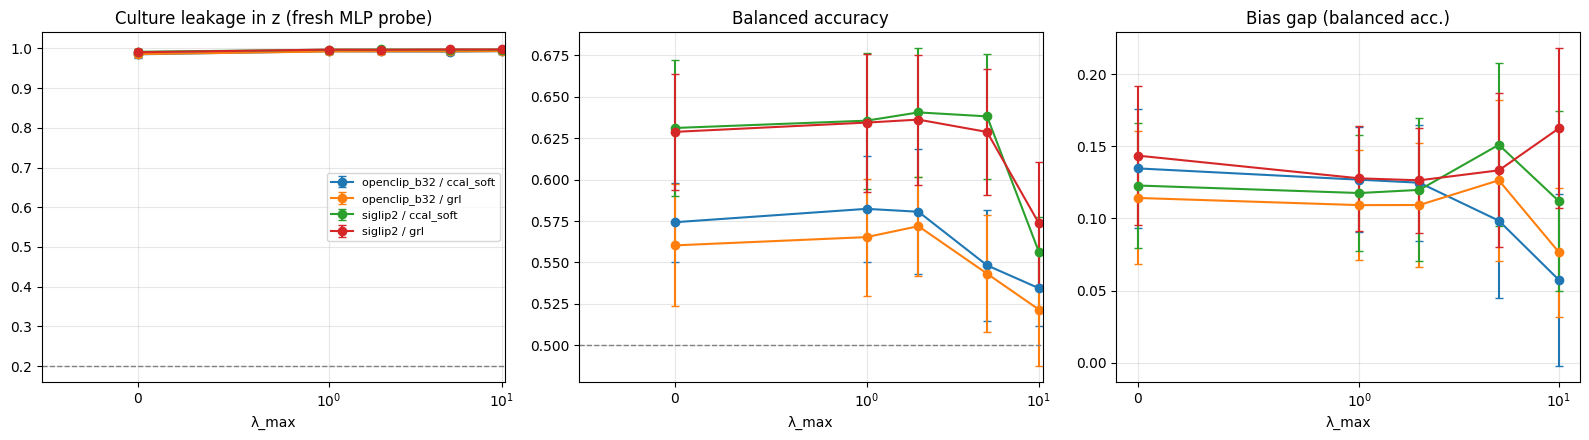

,backbone,variant,lambda,balanced_accuracy,auroc,worst_culture_bal_acc,bias_gap_bal_acc,equalized_odds_gap,ece,probe_z_linear_acc,probe_z_mlp_acc,degenerate
0,openclip_b32,ccal_soft,0.0,0.574,0.614,0.503,0.135,0.330,0.162,0.940,0.985,0/25
1,openclip_b32,ccal_soft,1.0,0.582,0.620,0.509,0.127,0.321,0.133,0.992,0.993,0/25
2,openclip_b32,ccal_soft,2.0,0.581,0.623,0.514,0.125,0.367,0.119,0.993,0.992,0/25
3,openclip_b32,ccal_soft,5.0,0.548,0.573,0.491,0.098,0.933,0.108,0.992,0.992,0/25
4,openclip_b32,ccal_soft,10.0,0.534,0.559,0.487,0.057,0.952,0.107,0.993,0.993,0/25
5,openclip_b32,grl,0.0,0.560,0.598,0.498,0.114,0.288,0.224,0.947,0.986,0/25
6,openclip_b32,grl,1.0,0.565,0.602,0.506,0.109,0.223,0.171,0.991,0.992,0/25
7,openclip_b32,grl,2.0,0.572,0.609,0.515,0.109,0.264,0.112,0.991,0.993,0/25
8,openclip_b32,grl,5.0,0.543,0.571,0.484,0.126,0.816,0.088,0.993,0.993,0/25
9,openclip_b32,grl,10.0,0.522,0.539,0.483,0.077,0.879,0.089,0.993,0.993,0/25


In [14]:
import matplotlib.pyplot as plt
KEYS = ["balanced_accuracy", "auroc", "worst_culture_bal_acc", "bias_gap_bal_acc",
        "equalized_odds_gap", "ece", "probe_z_linear_acc", "probe_z_mlp_acc"]
rows = []
for f in sorted(glob.glob(f"{RESULTS}/*/summary.json")):
    s = json.load(open(f))
    bk, rest = s["name"].split("_", 1) if s["name"].startswith("siglip2") else ("openclip_b32", s["name"][len("openclip_b32_"):])
    tag, lam = rest.rsplit("_lam", 1)
    r = {"backbone": bk, "variant": tag, "lambda": float(lam),
         "degenerate": f"{s['model']['degenerate_folds']}/{s['model']['n_folds']}"}
    for k in KEYS:
        v = s["model"].get(k)
        r[k], r[k + "_sd"] = (v["mean"], v["std"]) if v else (np.nan, np.nan)
    rows.append(r)
sweep = pd.DataFrame(rows).sort_values(["backbone", "variant", "lambda"]).reset_index(drop=True)
sweep.to_csv(f"{RESULTS}/lambda_sweep_table.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for (bk, tag), g in sweep.groupby(["backbone", "variant"]):
    lab = f"{bk} / {tag}"
    axes[0].errorbar(g["lambda"], g["probe_z_mlp_acc"], yerr=g["probe_z_mlp_acc_sd"], marker="o", capsize=3, label=lab)
    axes[1].errorbar(g["lambda"], g["balanced_accuracy"], yerr=g["balanced_accuracy_sd"], marker="o", capsize=3, label=lab)
    axes[2].errorbar(g["lambda"], g["bias_gap_bal_acc"], yerr=g["bias_gap_bal_acc_sd"], marker="o", capsize=3, label=lab)
axes[0].axhline(0.2, ls="--", c="gray", lw=1); axes[1].axhline(0.5, ls="--", c="gray", lw=1)
for ax, t in zip(axes, ["Culture leakage in z (fresh MLP probe)", "Balanced accuracy", "Bias gap (balanced acc.)"]):
    ax.set_title(t); ax.set_xlabel("λ_max"); ax.set_xscale("symlog", linthresh=1); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{RESULTS}/lambda_sweep.png", dpi=200); plt.show()

show = ["backbone", "variant", "lambda"] + KEYS + ["degenerate"]
sweep[show].round(3)

In [15]:
import shutil
shutil.make_archive("/kaggle/working/ccal_lambda_sweep", "zip", RESULTS)
print("Download /kaggle/working/ccal_lambda_sweep.zip from the Output tab.")

Download /kaggle/working/ccal_lambda_sweep.zip from the Output tab.


## What to send back
Upload **`ccal_lambda_sweep.zip`** from the Output tab (it contains `lambda_sweep_table.csv`, `lambda_sweep.png` and all per-fold predictions).